#Mood DJ: Music Mood Classifier and Recommender

Team Members:
1. Adib Mukhriz Abdul Malek (QZ5JJK)
2. Almási Júlia (ASTGQG)
3. Bartal Dávid (WB44U5)
4. Kiss Boróka (A0JMEA)

Dataset: Kaggle - "Audio-Emotion-Context-Dataset"
- https://www.kaggle.com/datasets/ziya07/audio-emotion-context-dataset
- we are using this dataset because it contains labeled emotional annotations that is suitable for supervised learning


In [1]:
#installing audio processing and UI library
!pip install -q -U librosa gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.6 MB/s eta 0:00:00


## Loading dataset

In [2]:
#connect google drive to colab
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
#the dataset is stored in google drive and it is quite large to be uploaded locally
#connection is succesful here and now we can access the dataset from the google drive

Mounted at /content/drive


In [3]:
df_emo_tag = pd.read_csv('/content/drive/MyDrive/MachineLearning/data/deam_emotion_tags.csv')
df_emo_tag.head()

,Track_ID,Title,Valence,Arousal,Emotion_Label
0,T0001,Song_1,0.37,0.35,Sad
1,T0002,Song_2,0.95,0.30,Relaxed
2,T0003,Song_3,0.73,0.35,Relaxed
3,T0004,Song_4,0.60,0.77,Happy
4,T0005,Song_5,0.16,0.66,Angry


In [4]:
#check unique emotion labels to understand classification categories
df_emo_tag["Emotion_Label"].unique()

array(['Sad', 'Relaxed', 'Happy', 'Angry'], dtype=object)

In [5]:
#check unique emotion labels to understand classification categories
# and check distribution of each emotion class
df_emo_tag["Emotion_Label"].value_counts()

,count
Emotion_Label,
Happy,485
Sad,448
Relaxed,437
Angry,432


In [6]:
#create filename column to match audio file naming format (T0001 → 1.mp3)
df_emo_tag["filename"] = df_emo_tag["Track_ID"].str.replace("T", "", regex=False).astype(int).astype(str) + ".mp3"

df_emo_tag.head()

,Track_ID,Title,Valence,Arousal,Emotion_Label,filename
0,T0001,Song_1,0.37,0.35,Sad,1.mp3
1,T0002,Song_2,0.95,0.30,Relaxed,2.mp3
2,T0003,Song_3,0.73,0.35,Relaxed,3.mp3
3,T0004,Song_4,0.60,0.77,Happy,4.mp3
4,T0005,Song_5,0.16,0.66,Angry,5.mp3


Although the dataset contains self-reported emotions, this project uses the provided emotion labels for model training. The self-reported emotions can be explored in future work for evaluation or recommendation enhancement.

##Audio Data Loading and Sampling
- Audio data is first loaded from Google Drive using the specified file path, similar to how the CSV files are accessed.
- The total number of audio files is checked, and since the dataset is relatively large, a subset of 500 audio files is randomly sampled to reduce computational cost and ensure efficient model training.

In [7]:
!ls /content/drive/MyDrive/MachineLearning/

archive.zip  data  processed_data


In [8]:
import os
import random
import numpy as np


#set seed for reproducibility
random.seed(17)
np.random.seed(17)

In [9]:
import os

# copy the files from google drive to colab storage to speed up processing of audio files
# if the folder already exists, skip this

if not os.path.exists('/content/local_audio/'):
    print("Local audio folder not found. Unzipping...")
    !cp /content/drive/MyDrive/MachineLearning/archive.zip /content/
    print('Copy complete')
    !unzip -q /content/archive.zip -d /content/local_audio/
    print("Unzip complete.")
else:
    print("Audio folder already exists. Skipping unzip.")

Local audio folder not found. Unzipping...
Copy complete
Unzip complete.


In [10]:
audio_path = '/content/local_audio/archive/DEAM_audio/MEMD_audio'

In [11]:
# old version, using GDrive mount
# audio_path = '/content/drive/MyDrive/MachineLearning/data/archive/DEAM_audio/MEMD_audio'

audio_files = os.listdir(audio_path)

print("Number of files found:", len(audio_files))
print(audio_files[:10])
# a total of 1802 audio files found

Number of files found: 1802
['1838.mp3', '1256.mp3', '1045.mp3', '1559.mp3', '2038.mp3', '214.mp3', '1228.mp3', '2032.mp3', '1207.mp3', '171.mp3']


In [12]:
# only keep rows in df_emo_tag which have a file!
df_emo_tag['exists'] = df_emo_tag['filename'].apply(lambda x: os.path.exists(os.path.join(audio_path, x)))
df_emo_tag = df_emo_tag[df_emo_tag['exists'] == True].copy()
df_emo_tag.reset_index(drop=True, inplace=True)

In [13]:
df_emo_tag.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Track_ID       1546 non-null   object 
 1   Title          1546 non-null   object 
 2   Valence        1546 non-null   float64
 3   Arousal        1546 non-null   float64
 4   Emotion_Label  1546 non-null   object 
 5   filename       1546 non-null   object 
 6   exists         1546 non-null   bool   
dtypes: bool(1), float64(2), object(4)
memory usage: 74.1+ KB


In [14]:
#sample 1500 audio files
sample_size = min(1500, len(df_emo_tag))

files = random.sample(audio_files, sample_size)

print("Number of selected files:", len(files))

Number of selected files: 1500


##Extract Mel-Frequency Cepstral Coefficients (MFCC) Features
- MFCC is a way to turn audio (sound) into numbers that a machine learning model can understand
- We need this because ML model can't understand raw audio directly so we convert it into matrix of numbers
- MFCC captures pitch, tone, sound quality and energy (basically how the audio/music sounds to people)
- more information can be found at: https://www.geeksforgeeks.org/nlp/mel-frequency-cepstral-coefficients-mfcc-for-speech-recognition/


In [15]:
import librosa
import numpy as np

#used 40 MFCC features as it provides a good balance between capturing sufficient audio detail and maintaining computational efficiency
def extract_mfcc(file_path, n_mfcc=40):
    #used sr=22050 since it is the standard sampling rate
    waveform, samplingrate = librosa.load(file_path, sr=22050)

    mfcc = librosa.feature.mfcc(y=waveform, sr=samplingrate, n_mfcc=n_mfcc) #converts raw audio into mfcc features

    mfcc = mfcc.T  #transpose to shape (time_steps, n_mfcc) for model compatibility
    return mfcc


In [16]:
#try sample, first random audio file
file = files[0]

file_path = os.path.join(audio_path, file)

mfcc = extract_mfcc(file_path)

print("MFCC shape:", mfcc.shape)

MFCC shape: (1938, 40)


This song is divided into 1938 small time slices (how long the song is),
and for each slice, we have 40 features describing the sound.

Now, we will create the datasets for our machine learning model

In [17]:
from tqdm import tqdm

#each song has different duration, so MFCC shapes are different
#CNN Model need same input size so we force all MFCC to same length
#sampling rate = 22050, librosa uses 512 hop length as default
#time per frame = hop length / sampling rate = ~ 0.023 seconds
#frames = seconds / time per frame
#decided to take 5 seconds (not too long and not too short) to reduce computational cost and ensure efficient model training
# 5/0.023 = 217 frames rounded ~215 frames

MAX_LEN = 215   #fixed time length
N_MFCC = 40
#every MFCC will become (215, 40)

def fix_mfcc_length(mfcc, max_len=MAX_LEN):

    #if audio length > 215 frames, take RANDOM segment
    if mfcc.shape[0] > max_len:
        start = np.random.randint(0, mfcc.shape[0] - max_len)
        mfcc = mfcc[start:start + max_len, :] #mfcc will sample randomly from random starting point

    # If audio length < 215, pad with zeros
    elif mfcc.shape[0] < max_len:
        pad_width = max_len - mfcc.shape[0]
        mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode="constant") #Zero-padding is applied to shorter audio samples to ensure consistent input size for the model by filling missing time steps with zeros.

    return mfcc

In [18]:
import os
import numpy as np
from tqdm import tqdm

# 1. Define paths on your Drive
save_path = '/content/drive/MyDrive/MachineLearning/processed_data/'
if not os.path.exists(save_path): os.makedirs(save_path)

x_file, y_file, cache_file = save_path+'X.npy', save_path+'y.npy', save_path+'feature_cache.npy'

# 2. Check if all files exist to skip extraction
if all(os.path.exists(f) for f in [x_file, y_file, cache_file]):
    print("Loading pre-computed features from Drive...")
    X = np.load(x_file)
    y = np.load(y_file)
    feature_cache = np.load(cache_file, allow_pickle=True).item()
else:
    print("Files not found. Starting extraction...")
    X, y, feature_cache, valid_indices = [], [], {}, []

    for idx, row in tqdm(df_emo_tag.iterrows(), total=len(df_emo_tag)):
        path = os.path.join(audio_path, row['filename'])
        if os.path.exists(path):
            try:
                feat = fix_mfcc_length(extract_mfcc(path))

                # used in CNN and recommender
                X.append(feat)
                y.append(row['Emotion_Label'])
                feature_cache[row['Track_ID']] = np.mean(feat, axis=0)
                valid_indices.append(idx)
            except: continue

    # save everything to save time
    X, y = np.array(X), np.array(y)
    np.save(x_file, X)
    np.save(y_file, y)
    np.save(cache_file, feature_cache)
    print("Data saved to Drive for future use.")

# Sync dataframe to match the loaded/extracted features
if 'valid_indices' in locals():
    df_final = df_emo_tag.loc[valid_indices].reset_index(drop=True)
else:
    df_final = df_emo_tag.copy()

print(f"Final Data Ready: X={X.shape}, y={y.shape}, Cache={len(feature_cache)} items")

Loading pre-computed features from Drive...
Final Data Ready: X=(1546, 215, 40), y=(1546,), Cache=1546 items


From the result, 1546 audio files were successfully processed and used for the dataset.

Each audio sample is represented as a matrix of size (215, 40), where:
- 215 represents the number of time frames (~5 seconds of audio)
- 40 represents the number of MFCC features

The labels show that there are 4 emotion classes: Angry, Happy, Relaxed, and Sad.

Some audio files were excluded because they did not have matching emotion labels in the dataset.

In [19]:
#converting text labels into numbers
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder() #create encoder object

y_encoded = label_encoder.fit_transform(y) #learn all unique labels and convert them into numbers, we are using the y list from the previous cell

print("Original labels:", label_encoder.classes_)
print("Encoded labels:", np.unique(y_encoded))
print("Example:", y[:5], "->", y_encoded[:5])
# ML models require numeric labels, so we convert emotion text into numbers

Original labels: ['Angry' 'Happy' 'Relaxed' 'Sad']
Encoded labels: [0 1 2 3]
Example: ['Relaxed' 'Relaxed' 'Happy' 'Angry' 'Sad'] -> [2 2 1 0 3]


In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, # x list of MFCC features
    y_encoded, #numeric emotion labels
    test_size=0.2, #20% for testing and 80% for training
    random_state=42, #for reproducibility
    stratify=y_encoded
) #create 4 datasets for training and testing

print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1236, 215, 40)
X_test shape: (310, 215, 40)
y_train shape: (1236,)
y_test shape: (310,)


x_train:
- 1236 samples (songs)
- each = (215 time frames × 40 MFCC features)

x_test:
- 310 samples (songs)
- same structure

y_train, y_test
- contain the corresponding emotion labels
- each sample has one label (encoded as a number)

The resulting dataset is well-structured and ready for model training, with consistent MFCC feature dimensions across all samples.

##Building Concolutional Neural Network (CNN)
- CNN - type of neural network designed to detext patterns in grid-like data
- Since MFCC is like an image-like data, we use CNN because it is designed for 2D structured data, thus will allow the model to learn local patterns in the audio that are relevant for mood classification

In [21]:
import torch

#convert numpy arrays to tensors and add channel dimension (for CNN)
x_train_tensor = torch.tensor(x_train, dtype=torch.float32).unsqueeze(1)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).unsqueeze(1)

#convert labels to tensor (integer type for classification)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train_tensor:", x_train_tensor.shape)
print("X_test_tensor:", x_test_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([1236, 1, 215, 40])
X_test_tensor: torch.Size([310, 1, 215, 40])
y_train_tensor: torch.Size([1236])
y_test_tensor: torch.Size([310])


CNN requires channel dimension, hence with unsqueeze(1), we add a new "channels" dimension into the tensor to avoid model error

In [22]:
#tensordataset combines x and y together and dataloader feeds data to model in batches
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of testing batches:", len(test_loader))

Number of training batches: 39
Number of testing batches: 10


Batch size influences the learning dynamics of the model. Smaller batch sizes introduce more variability during training, which can improve generalization, while larger batch sizes provide more stable updates but may lead to overfitting. A batch size of 32 was chosen as a balanced trade-off between training stability and generalization performance.

CNN Model Architecture

In [23]:
import torch.nn as nn
import torch.nn.functional as F

class MoodCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(MoodCNN, self).__init__()

        #first convolution layer: learns simple local patterns from MFCC
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) # for stability

        #pooling layer: reduces feature size and computation
        self.pool = nn.MaxPool2d(2, 2)

        #second convolution layer: learns deeper audio patterns
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # third convolutional layer: deeper audio pattern recognition
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        #adaptive pooling makes the output size fixed
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        #fully connected layers for final classification
        self.fc1 = nn.Linear(64, 128)

        # try not to memorize training data
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) #apply first convolution, ReLU activation, and pooling

        x = self.pool(F.relu(self.bn2(self.conv2(x)))) #apply second convolution, ReLU activation, and pooling

        x = self.pool(F.relu(self.bn3(self.conv3(x)))) #apply second convolution, ReLU activation, and pooling

        x = self.adaptive_pool(x) #force output to fixed size

        x = x.view(x.size(0), -1) #flatten feature maps into one vector

        x = F.relu(self.fc1(x)) #fully connected layer

        x = self.dropout(x)

        x = self.fc2(x) #output layer gives scores for each mood class

        return x

In [24]:
model = MoodCNN(num_classes=4)

print(model)

MoodCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


##Model training

Cross-entropy loss for multi-class classification and Adam optimizer

Epoch 1/50 - Loss: 1.4045
Epoch 2/50 - Loss: 1.3878
Epoch 3/50 - Loss: 1.3837
Epoch 4/50 - Loss: 1.3921
Epoch 5/50 - Loss: 1.3827
Epoch 6/50 - Loss: 1.3814
Epoch 7/50 - Loss: 1.3847
Epoch 8/50 - Loss: 1.3831
Epoch 9/50 - Loss: 1.3836
Epoch 10/50 - Loss: 1.3863
Epoch 11/50 - Loss: 1.3813
Epoch 12/50 - Loss: 1.3773
Epoch 13/50 - Loss: 1.3817
Epoch 14/50 - Loss: 1.3840
Epoch 15/50 - Loss: 1.3764
Epoch 16/50 - Loss: 1.3794
Epoch 17/50 - Loss: 1.3761
Epoch 18/50 - Loss: 1.3764
Epoch 19/50 - Loss: 1.3755
Epoch 20/50 - Loss: 1.3746
Epoch 21/50 - Loss: 1.3717
Epoch 22/50 - Loss: 1.3683
Epoch 23/50 - Loss: 1.3677
Epoch 24/50 - Loss: 1.3664
Epoch 25/50 - Loss: 1.3705
Epoch 26/50 - Loss: 1.3652
Epoch 27/50 - Loss: 1.3643
Epoch 28/50 - Loss: 1.3686
Epoch 29/50 - Loss: 1.3623
Epoch 30/50 - Loss: 1.3580
Epoch 31/50 - Loss: 1.3591
Epoch 32/50 - Loss: 1.3552
Epoch 33/50 - Loss: 1.3541
Epoch 34/50 - Loss: 1.3500
Epoch 35/50 - Loss: 1.3478
Epoch 36/50 - Loss: 1.3478
Epoch 37/50 - Loss: 1.3509
Epoch 38/5

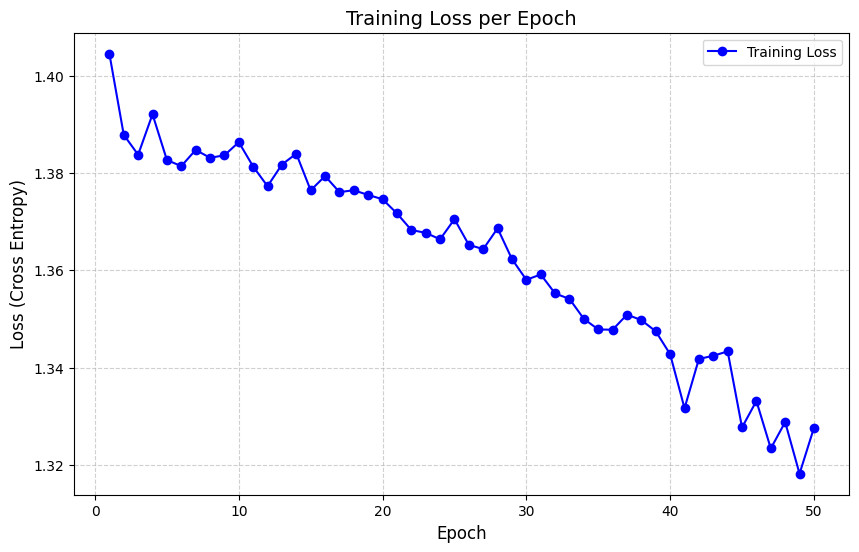

In [25]:
import torch.optim as optim

#Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

#Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


#List to store loss values
history = []

EPOCHS = 50
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    #Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    history.append(epoch_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {epoch_loss:.4f}")

#Visual
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), history, marker='o', color='b', label='Training Loss')
plt.title('Training Loss per Epoch', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Cross Entropy)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [26]:
torch.save(
    model.state_dict(),
    "mood_cnn_model.pth"
)
print("CNN model saved successfully.")

CNN model saved successfully.


##Model evaluation

Comparison to baseline model, random forest/SVM (good for audio data).
Evaluation metrics; accuracy.


In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix)

model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_predictions)

print(f'Accuracy on test set: {100 * accuracy:.2f}%')

print("\nClassification report:\n")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_))

# confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

print("\nConfusion matrix:\n")
print(cm)

Accuracy on test set: 29.68%

Classification report:

              precision    recall  f1-score   support

       Angry       0.25      0.28      0.27        75
       Happy       0.31      0.57      0.40        84
     Relaxed       0.31      0.26      0.28        76
         Sad       0.50      0.04      0.07        75

    accuracy                           0.30       310
   macro avg       0.34      0.29      0.26       310
weighted avg       0.34      0.30      0.26       310


Confusion matrix:

[[21 35 17  2]
 [20 48 15  1]
 [24 32 20  0]
 [18 41 13  3]]


In [28]:
# Convert tensors back to numpy for Scikit-Learn
x_train_np = x_train_tensor.squeeze(1).numpy()
x_test_np = x_test_tensor.squeeze(1).numpy()

# Flatten features by taking the mean across the time dimension (axis 1)
x_train_flat = np.mean(x_train_np, axis=1)
x_test_flat = np.mean(x_test_np, axis=1)

Compare to random forest

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize and train random forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=11)
rf_model.fit(x_train_flat, y_train)

# Predict and evaluate
rf_preds = rf_model.predict(x_test_flat)
print(f"Random Forest Accuracy: {100 * accuracy_score(y_test, rf_preds):.2f}%")

Random Forest Accuracy: 23.55%


Compare to SVM

In [30]:
from sklearn.svm import SVC

# Initialize and train (RBF kernel is often best for audio)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=11)
svm_model.fit(x_train_flat, y_train)

# Predict and evaluate
svm_preds = svm_model.predict(x_test_flat)
print(f"SVM Accuracy: {100 * accuracy_score(y_test, svm_preds):.2f}%")

SVM Accuracy: 27.42%


Model comparison

In [31]:
cnn_accuracy = accuracy
rf_accuracy = accuracy_score(y_test, rf_preds)
svm_accuracy = accuracy_score(y_test, svm_preds)

print(f"CNN accuracy: {100*cnn_accuracy:.3f}%")
print(f"Random Forest accuracy: {100*rf_accuracy:.3f}%")
print(f"SVM accuracy: {100*svm_accuracy:.3f}%")

CNN accuracy: 29.677%
Random Forest accuracy: 23.548%
SVM accuracy: 27.419%


##Song recommendation

The "DJ" part of the project needs to suggest a song. Since our dataset has limited samples, a simple Content-Based Filtering approach works best:

1. Classify the user's current "vibe" (or a target song).
2. Filter the library for songs with that same predicted label.

In [32]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_songs(input_audio_path, library_df, top_n=5):
    #Extract & Fix MFCC from the uploaded
    feat = extract_mfcc(input_audio_path)
    feat = fix_mfcc_length(feat)
    input_vector = np.mean(feat, axis=0).reshape(1, -1)
    feat_tensor = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).unsqueeze(1).to(device)

    print(f"Feat tensor size {feat_tensor.shape}")

    #Predict Mood
    model.eval()
    print('Running model')
    with torch.no_grad():
        output = model(feat_tensor)
        predicted_class = torch.argmax(output, dim=1).item()
        mood = label_encoder.inverse_transform([predicted_class])[0]
        print(f"Predicted mood: {mood}")

    print(f"Getting suggestions")

    #Suggest from library
    suggestions = library_df[library_df['Emotion_Label'] == mood].copy()

    similarities = []
    for idx, row in suggestions.iterrows():
        track_id = row['Track_ID']
        if track_id in feature_cache:
            lib_vector = feature_cache[track_id].reshape(1, -1)
            sim = cosine_similarity(input_vector, lib_vector)[0][0]
            similarities.append(sim)
        else:
            similarities.append(0)

    suggestions['similarity_score'] = similarities

    #Return top N most similar tracks
    recommendations = suggestions.sort_values(by='similarity_score', ascending=False).head(top_n)
    print(recommendations)
    recommended_paths = [os.path.join(audio_path, f) for f in recommendations['filename']]
    return mood, recommendations[['Track_ID', 'Title', 'similarity_score']], recommended_paths

In [33]:
# test
mood, playlist, path = recommend_songs(os.path.join(audio_path, files[0]), df_emo_tag)

Feat tensor size torch.Size([1, 1, 215, 40])
Running model
Predicted mood: Happy
Getting suggestions
     Track_ID      Title  Valence  Arousal Emotion_Label  filename  exists  \
1137    T1394  Song_1394     0.52     0.51         Happy  1394.mp3    True   
1374    T1631  Song_1631     0.76     0.76         Happy  1631.mp3    True   
892     T1149  Song_1149     0.85     0.83         Happy  1149.mp3    True   
399     T0485   Song_485     0.58     0.97         Happy   485.mp3    True   
911     T1168  Song_1168     0.51     0.50         Happy  1168.mp3    True   

      similarity_score  
1137          0.994072  
1374          0.989062  
892           0.987795  
399           0.986228  
911           0.986154  


#Interface with Gradio

The Gradio package has a built-in gr.Audio component that allows you to either upload a file or record directly from your microphone so that's what we use for the demo.

In [34]:
import gradio as gr

def mood_dj_interface(audio_file):
    if audio_file is None:
        return "Please upload an audio file.", None

    #Use existing recommendation logic
    #This calls the function created earlier
    mood, recommendations, paths = recommend_songs(audio_file, df_emo_tag)

    #Format the output for the UI
    rec_text = recommendations[['Track_ID', 'Title', 'similarity_score']]#.to_string(index=False)

    return mood, rec_text, paths[0]

# kill previous running instances
try:
  demo.close()
except:
  pass

gr.close_all()

#Gradio Interface
demo = gr.Interface(
    fn=mood_dj_interface,
    inputs=gr.Audio(type="filepath", label="Upload a Song"),
    outputs=[
        gr.Textbox(label="Predicted Mood"),
        gr.DataFrame(label='Top 5 recommendations'),
        gr.Audio(label='Top recommendation', type='filepath')
        #gr.Textbox(label="Top 5 Recommendations")
    ],
    title="🎵 Mood DJ: AI Music Recommender",
    description="Upload any music, and our CNN will recommend similar vibes!"
)

#share=True creates a public link
demo.launch(share=True, show_error=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0a5ca1055f2e51a4dc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
